# Topic Modeling & Temporal Evolution — Archelec corpus

Author: Emma Leguay, ENSAE 3A - MiE M2, 2025-2026

In [1]:
# Imports
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import time
from archelec_topics.loader import load_corpus
from archelec_topics.description import column_overview, value_distribution, text_statistics, temporal_distribution
from archelec_topics.occupations_processing import add_occupation_columns, print_occupation_diagnostic, CATEGORY_ORDER
from archelec_topics.parties_processing import add_party_columns, print_party_diagnostic, FAMILY_ORDER
from archelec_topics.preprocessing import preprocess_corpus, inspect_documents, summarize_token_frequencies, summarize_compound_hits, EXTRA_STOPWORDS
from archelec_topics.models import LDATopicModel, NMFTopicModel, BERTopicModel, compute_embeddings
from archelec_topics.evaluation import summarize_model, sweep_n_topics
from archelec_topics.interpretation import topic_words_dataframe, make_label_template, find_representative_documents, apply_labels, align_topics
from archelec_topics.visualisation import plot_topic_words, plot_topic_wordclouds, plot_doc_topic_heatmap, plot_topic_prevalence_over_time, plot_topic_alignment_matrix, plot_bertopic_topics_over_time
from archelec_topics.topic_metadata_analysis import topics_by_party, topics_by_family, top_topics_per_group, plot_topic_group_heatmap, plot_group_topic_profile

pd.set_option("display.max_columns", None)   # show all columns
plt.rcParams.update({                        # NeurIPS-style matplotlib settings
    # Figure
    "figure.figsize":    (6.5, 3.5),         # NeurIPS column width is ~5.5", full page ~6.75"
    "figure.dpi":        100,
    "savefig.dpi":       300,                # high DPI for crisp publication output
    "savefig.bbox":      "tight",
    "savefig.pad_inches": 0.05,
    
    # Fonts — Times New Roman to match the NeurIPS LaTeX template
    "font.family":       "serif",
    "font.serif":        ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset":  "stix",             # serif math that matches Times
    
    # Sizes (NeurIPS uses 10pt body text)
    "font.size":         11,
    "axes.titlesize":    13,
    "axes.labelsize":    11,
    "xtick.labelsize":   10,
    "ytick.labelsize":   10,
    "legend.fontsize":   10,
    
    # Axes
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.linewidth":     0.8,
    "axes.grid":          True,
    "grid.alpha":         0.25,
    "grid.linestyle":     "-",
    "grid.linewidth":     0.4,
    
    # Ticks
    "xtick.direction":   "out",
    "ytick.direction":   "out",
    "xtick.major.size":  3,
    "ytick.major.size":  3,
    
    # Lines & markers
    "lines.linewidth":   1.2,
    "lines.markersize":  4,
    
    # Legend
    "legend.frameon":    False,
    
    # Colors — colorblind-safe palette (Paul Tol's "muted")
    "axes.prop_cycle": plt.cycler(
        color=["#332288", "#117733", "#882255", "#88CCEE",
               "#DDCC77", "#CC6677", "#44AA99", "#AA4499"]
    ),
})

In [2]:
# Constant variables for the whole file

DATA_DIR = Path("./data")
METADATA_CSV = "archelect_search.csv"
TRANSCRIPTIONS_DIR = "arkindex_archelec/text_files"

FIRST_RUN = True # Set to False after the first run to skip preprocessing and load pickled tokens instead

## 1. The data : loading, pre-processing and analyzing

### 1.1 Load the full corpus with metadata

In [3]:
# Load the full corpus

df_full = load_corpus(
    metadata_csv   = DATA_DIR / METADATA_CSV,
    text_files_dir = DATA_DIR / TRANSCRIPTIONS_DIR,
)
print(df_full.shape)
df_full.head(3)

/Users/emmaleguay/Library/CloudStorage/OneDrive-HECParis/2025-2026-3A-ENSAE-MiE/S2/ML pour NLP/Archelec_NLP_topic_analysis/archelec_topics/loader.py:47: DtypeWarning: Columns (0: departement-nom, 1: departement-insee, 2: identifiant de circonscription, 3: pdf, 4: suppleant-nom, 5: suppleant-prenom, 6: suppleant-sexe, 7: suppleant-age, 8: suppleant-age-calcule, 9: suppleant-age-tranche, 10: suppleant-profession, 11: suppleant-mandat-en-cours, 12: suppleant-mandat-passe, 13: suppleant-associations, 14: suppleant-autres-statuts, 15: suppleant-soutien, 16: suppleant-liste, 17: suppleant-decorations) have mixed types. Specify dtype option on import or set low_memory=False.
  metadata = pd.read_csv(metadata_csv)


(21697, 43)


,id,text,date,subject,title,contexte-election,contexte-tour,cote,departement,departement-nom,departement-insee,identifiant de circonscription,images,pdf,ocr_url,titulaire-nom,titulaire-prenom,titulaire-sexe,titulaire-age,titulaire-age-calcule,titulaire-age-tranche,titulaire-profession,titulaire-mandat-en-cours,titulaire-mandat-passe,titulaire-associations,titulaire-autres-statuts,titulaire-soutien,titulaire-liste,titulaire-decorations,suppleant-nom,suppleant-prenom,suppleant-sexe,suppleant-age,suppleant-age-calcule,suppleant-age-tranche,suppleant-profession,suppleant-mandat-en-cours,suppleant-mandat-passe,suppleant-associations,suppleant-autres-statuts,suppleant-soutien,suppleant-liste,suppleant-decorations
0,EL175_L_1988_06_037_03_1_PF_03,Sciences Po / fonds CEVIPOF\nLA FRANCE UNIE\nA...,1988-06-05,Ve République;Élections législatives;Assemblée...,"Élections législatives de 1988, Indre-et-Loire...",législatives,1.0,EL175,37,Indre-et-Loire,37 - Indre-et-Loire,3,https://ia801504.us.archive.org/2/items/EL175_...,https://ia801504.us.archive.org/2/items/EL175_...,https://ia801504.us.archive.org/2/items/EL175_...,Mora,Christiane,femme,non mentionné,non mentionné,non mentionné,non mentionné,non mentionné,député sortant,non mentionné,non mentionné,non mentionné,Majorité présidentielle pour la France unie,non,Boussiquet,Henri,homme,non mentionné,non mentionné,non mentionné,non mentionné,non mentionné,non mentionné,syndicat,non mentionné,non mentionné,Majorité présidentielle pour la France unie,non
1,EL177_L_1988_06_078_05_1_PF_01,ELECTIONS LEGISLATIVES DES 5 ET 12 JUIN 1988\n...,1988-06-05,Élections législatives;France;Ve République;As...,"Élections législatives de 1988, Yvelines - 78,...",législatives,1.0,EL177,78,Yvelines,78 - Yvelines (Seine-et-Oise),5,https://ia801807.us.archive.org/33/items/EL177...,https://ia801807.us.archive.org/33/items/EL177...,https://ia801807.us.archive.org/33/items/EL177...,Jonemann,Alain,homme,non mentionné,non mentionné,non mentionné,expert judiciaire,maire;conseiller général,conseiller régional,non mentionné,non mentionné,Rassemblement pour la République,Union du rassemblement et du centre,oui,Wetzel,Laurent,homme,non mentionné,non mentionné,non mentionné,professeur,conseiller municipal;conseiller général,non mentionné,non mentionné,non mentionné,Union pour la démocratie française,Union du rassemblement et du centre,non
2,EL175_L_1988_06_049_06_1_PF_04,Sciences Po / fonds CEVIPOF\nLA FRANCE UNIE\nA...,1988-06-05,France;Assemblée Nationale;Élections législati...,"Élections législatives de 1988, Maine-et-Loire...",législatives,1.0,EL175,49,Maine-et-Loire,49 - Maine-et-Loire,6,https://ia801809.us.archive.org/19/items/EL175...,https://ia801809.us.archive.org/19/items/EL175...,https://ia801809.us.archive.org/19/items/EL175...,Bordier,François,homme,non mentionné,non mentionné,non mentionné,enseignant,non mentionné,non mentionné,non mentionné,non mentionné,Parti socialiste,Majorité présidentielle pour la France unie,non,Palussiere,Victor,homme,non mentionné,non mentionné,non mentionné,non mentionné,conseiller municipal,non mentionné,non mentionné,non mentionné,Parti socialiste,Majorité présidentielle pour la France unie,non


### 1.2. Analysis of the corpus

### First overall analysis

In [4]:
# Column overview to understand the structure of the dataset and identify key variables for analysis

column_overview(df_full)

,column,dtype,n_non_null,n_unique,example
0,id,str,21697,21697,EL175_L_1988_06_037_03_1_PF_03
1,date,str,21167,11,1988-06-05
2,subject,str,21167,26,Ve République;Élections législatives;Assemblée...
3,title,str,21167,20969,"Élections législatives de 1988, Indre-et-Loire..."
4,contexte-election,str,21167,1,législatives
5,contexte-tour,float64,21167,2,1.0
6,cote,str,21167,30,EL175
7,departement,str,21167,106,37
8,departement-nom,str,21167,108,Indre-et-Loire
9,departement-insee,str,21167,106,37 - Indre-et-Loire


In [5]:
# Reduce DataFrame to relevant columns
keep_columns = [
    # Identifier and content
    "id",
    "text",
    
    # Archival metadata
    "subject",
    "title",
    "cote",
    
    # Temporal & geographic dimensions
    "date",
    "departement-nom",
    "departement-insee",
    "identifiant de circonscription",
    
    # Round of election
    "contexte-tour",
    
    # Candidate sociodemographic features
    "titulaire-sexe",
    "titulaire-age-tranche",
    "titulaire-profession",
    
    # Candidate political affiliation
    "titulaire-soutien",
    "titulaire-liste",
    
    # Candidate political experience
    "titulaire-mandat-en-cours",
    "titulaire-mandat-passe",
]

df = df_full[keep_columns].copy()

# Extract year from date for downstream temporal analyses
df["year"] = pd.to_datetime(df["date"], errors="coerce").dt.year
df["date"] = pd.to_datetime(df["date"], errors="coerce")

print(f"Reduced from {df_full.shape[1]} to {df.shape[1]} columns")
print(f"Year range: {df['year'].min():.0f}–{df['year'].max():.0f}")

Reduced from 43 to 18 columns
Year range: 1973–1993


In [6]:
# More detailed variable distributions on key columns

key_cols = ["date", "contexte-election", "contexte-tour", "titulaire-soutien", "titulaire-liste", "titulaire-sexe", "titulaire-age-tranche", "titulaire-profession", "titulaire-mandat-en-cours", "titulaire-mandat-passe"]
for col in key_cols:
    print(f"\n=== {col} ===")
    print(value_distribution(df_full, col, top_n=20))


=== date ===
            n_documents  proportion
date                               
1993-03-21         4872    0.224547
1978-03-12         4007    0.184680
1973-03-04         2922    0.134673
1988-06-05         2685    0.123750
1981-06-14         2468    0.113748
1993-03-28          965    0.044476
1973-03-11          921    0.042448
1988-06-12          854    0.039360
1978-03-19          817    0.037655
1981-06-21          653    0.030096
NaN                 530    0.024427
1978-03-01            3    0.000138

=== contexte-election ===
                   n_documents  proportion
contexte-election                         
législatives             21167    0.975573
NaN                        530    0.024427

=== contexte-tour ===
               n_documents  proportion
contexte-tour                         
1.0                  16957    0.781537
2.0                   4210    0.194036
NaN                    530    0.024427

=== titulaire-soutien ===
                                      

#### Overall

The full Archelec corpus consists of **21,697 OCRed political manifestos** from
French legislative elections, joined with metadata exported from the Archelec
Sciences Po explorer. The metadata covers **only legislative elections**
(`contexte-election` is constant), so the temporal evolution analysis will
contrast different legislative cycles rather than different election types.

#### Quality of the join

530 transcriptions (~2.4%) have no corresponding metadata in the CSV because there are in fact "bulletin de vote" and not "professions de foi". These
are likely documents that were OCR'd but not yet catalogued, or files with
identifier mismatches. We discard them, leaving **21,167 documents** with
both text and metadata.

#### Structure of the corpus

After filtering, the corpus covers **11 distinct election dates** spanning
several decades of the Ve Republic. Each document corresponds to one
candidate (`titulaire`) running in a specific *circonscription*. About
**78%** of documents are first-round manifestos and **19%** are second-round
manifestos.

#### Coverage of candidate metadata

Coverage varies considerably across metadata fields:

- **Sex** is reliably recorded (98% non-missing) — 84% men, 10% women,
  4% undetermined. Female representation is low, as expected from the
  sociology of French legislative candidates over the period.
- **Political affiliation** (`titulaire-soutien`) is missing for 18% of
  candidates. The 1,523 unique values are inflated by alliance strings
  (e.g., *"RPR;UDF"*); the underlying distinct parties are far fewer
  and will need to be normalized for cross-tabulations.
- **Profession** is missing for 44% of candidates, which restricts any
  topic × profession analysis to roughly half of the corpus. Among
  documented professions, liberal professions (lawyers, doctors,
  engineers) and teaching dominate, consistent with known patterns of
  candidate sociology.

These coverage gaps shape what kind of cross-analyses are statistically
meaningful and are reported alongside results in later sections.

In [7]:
# Implement some fixes

# Drop rows where text is missing (the only column that really matters)
before = len(df)
df = df.dropna(subset=["text"]).reset_index(drop=True)
print(f"Dropped {before - len(df)} rows without text, {len(df)} remaining")

# Drop rows which are not "professions de foi" but actually "bulletin de vote"
# Identified by the fact that they have no corresponding ID in the metadata csv
before = len(df)
df = df.dropna(subset=["date"]).reset_index(drop=True)
print(f"Dropped {before - len(df)} rows without text, {len(df)} remaining")

# Fix the 1978 anomaly: 3 dates instead of 2 (1st and 2nd round)
mask = df["date"] == "1978-03-01"
print(f"Fixing {mask.sum()} rows with date 1978-03-01")
df.loc[mask, "date"] = "1978-03-12"

# Replace 'non mentionné' with NaN across all string columns
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].replace("non mentionné", pd.NA)

# Right format for integer variables
df["contexte-tour"] = df["contexte-tour"].astype("Int64")
df["identifiant de circonscription"] = pd.to_numeric(
    df["identifiant de circonscription"], errors="coerce"
).astype("Int64")

# Reput the date column in datetime format after fixing the 1978 anomaly
df["date"] = pd.to_datetime(df["date"], errors="coerce").dt.date
df["year"] = pd.to_datetime(df["date"], errors="coerce").dt.year

# Create dummy variables for current and past mandates
df["dummy_titulaire_mandat_en_cours"] = df["titulaire-mandat-en-cours"].notna().astype(int)
df["dummy_titulaire_mandat_passe"]    = df["titulaire-mandat-passe"].notna().astype(int)

print(df[["dummy_titulaire_mandat_en_cours", "dummy_titulaire_mandat_passe"]].sum())
df.head(5)

Dropped 0 rows without text, 21697 remaining
Dropped 530 rows without text, 21167 remaining
Fixing 3 rows with date 1978-03-01


/var/folders/wg/135c97bj1s97wh3d6qqx1vgw0000gn/T/ipykernel_67086/4077373508.py:20: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


dummy_titulaire_mandat_en_cours    8759
dummy_titulaire_mandat_passe       4349
dtype: int64


,id,text,subject,title,cote,date,departement-nom,departement-insee,identifiant de circonscription,contexte-tour,titulaire-sexe,titulaire-age-tranche,titulaire-profession,titulaire-soutien,titulaire-liste,titulaire-mandat-en-cours,titulaire-mandat-passe,year,dummy_titulaire_mandat_en_cours,dummy_titulaire_mandat_passe
0,EL175_L_1988_06_037_03_1_PF_03,Sciences Po / fonds CEVIPOF\nLA FRANCE UNIE\nA...,Ve République;Élections législatives;Assemblée...,"Élections législatives de 1988, Indre-et-Loire...",EL175,1988-06-05,Indre-et-Loire,37 - Indre-et-Loire,3,1,femme,NaN,NaN,NaN,Majorité présidentielle pour la France unie,NaN,député sortant,1988,0,1
1,EL177_L_1988_06_078_05_1_PF_01,ELECTIONS LEGISLATIVES DES 5 ET 12 JUIN 1988\n...,Élections législatives;France;Ve République;As...,"Élections législatives de 1988, Yvelines - 78,...",EL177,1988-06-05,Yvelines,78 - Yvelines (Seine-et-Oise),5,1,homme,NaN,expert judiciaire,Rassemblement pour la République,Union du rassemblement et du centre,maire;conseiller général,conseiller régional,1988,1,1
2,EL175_L_1988_06_049_06_1_PF_04,Sciences Po / fonds CEVIPOF\nLA FRANCE UNIE\nA...,France;Assemblée Nationale;Élections législati...,"Élections législatives de 1988, Maine-et-Loire...",EL175,1988-06-05,Maine-et-Loire,49 - Maine-et-Loire,6,1,homme,NaN,enseignant,Parti socialiste,Majorité présidentielle pour la France unie,NaN,NaN,1988,0,0
3,EL175_L_1988_06_054_06_1_PF_05,"PARTI OUVRIER EUROPÉEN Siège : 19, rue Nollet,...",Ve République;Élections législatives;France;As...,"Élections législatives de 1988, Meurthe-et-Mos...",EL175,1988-06-05,Meurthe-et-Moselle,54 - Meurthe-et-Moselle,6,1,non déterminé,NaN,NaN,Parti ouvrier européen,NaN,NaN,NaN,1988,0,0
4,EL177_L_1988_06_094_05_1_PF_06,"PARTI OUVRIER EUROPÉEN Siège : 19, rue Nollet,...",France;Élections législatives;Assemblée Nation...,"Élections législatives de 1988, Val-de-Marne -...",EL177,1988-06-05,Val-de-Marne,94 - Val-de-Marne,5,1,non déterminé,NaN,NaN,Parti ouvrier européen,NaN,NaN,NaN,1988,0,0


### Visual representation of the corpus for further analysis

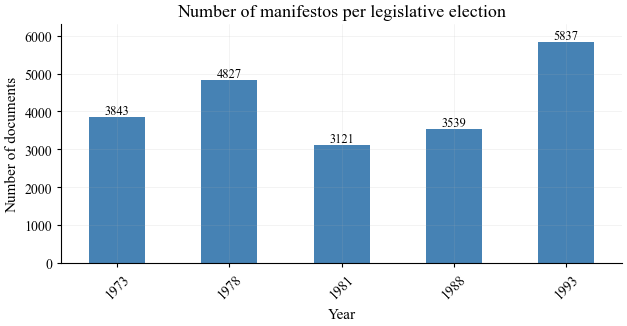

In [8]:
# Documents per legislative election year

docs_per_year = df["year"].value_counts().sort_index()
docs_per_year.index = docs_per_year.index.astype(int).astype(str)

fig, ax = plt.subplots(figsize=(6.5, 3.5))
docs_per_year.plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Number of manifestos per legislative election")
ax.set_xlabel("Year")
ax.set_ylabel("Number of documents")
ax.tick_params(axis="x", rotation=45)

for i, v in enumerate(docs_per_year.values):
    ax.text(i, v, str(v), ha="center", va="bottom", fontsize=9)
ax.set_ylim(0, docs_per_year.max() * 1.08)

plt.tight_layout()
plt.savefig("charts/01_docs_per_year.png", dpi=150)
plt.show()

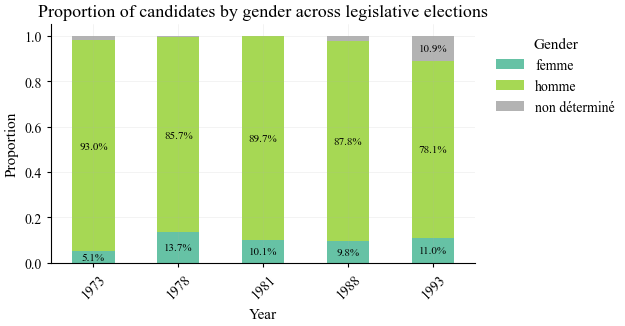

In [9]:
# Gender distribution over time — illustrates the slow feminization of candidacies
gender_over_time = temporal_distribution(df, group_col="titulaire-sexe")

# Convert to proportions per year
gender_props = gender_over_time.div(gender_over_time.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(6.5, 3.5))
gender_props.plot(kind="bar", stacked=True, ax=ax, colormap="Set2")
ax.set_title("Proportion of candidates by gender across legislative elections")
ax.set_xlabel("Year")
ax.set_ylabel("Proportion")
ax.legend(title="Gender", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.tick_params(axis="x", rotation=45)

for container in ax.containers:
    labels = [f"{v.get_height()*100:.1f}%" if v.get_height() > 0.03 else ""
              for v in container]
    ax.bar_label(container, labels=labels, label_type="center", fontsize=8)

plt.tight_layout()
plt.savefig("charts/02a_gender_over_time.png", dpi=150)
plt.show()

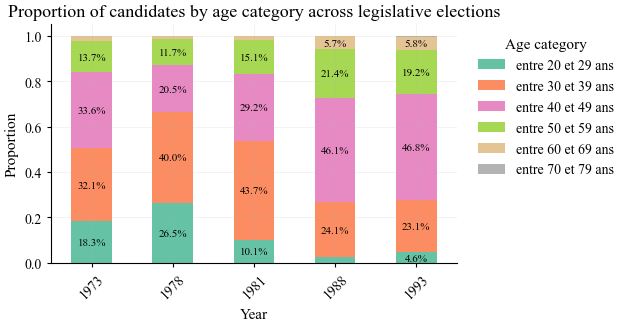

In [10]:
# Age distribution over time — politicians gets older or younger ?
age_over_time = temporal_distribution(df, group_col="titulaire-age-tranche")

# Convert to proportions per year
age_props = age_over_time.div(age_over_time.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(6.5, 3.5))
age_props.plot(kind="bar", stacked=True, ax=ax, colormap="Set2")
ax.set_title("Proportion of candidates by age category across legislative elections")
ax.set_xlabel("Year")
ax.set_ylabel("Proportion")
ax.legend(title="Age category", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.tick_params(axis="x", rotation=45)

for container in ax.containers:
    labels = [f"{v.get_height()*100:.1f}%" if v.get_height() > 0.03 else ""
              for v in container]
    ax.bar_label(container, labels=labels, label_type="center", fontsize=8)

plt.tight_layout()
plt.savefig("charts/02b_age_over_time.png", dpi=150)
plt.show()

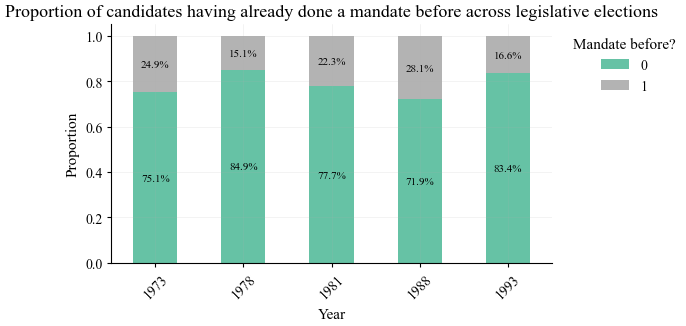

In [11]:
# Mandate_before distribution over time — is there a professionalisation of the politics?
mandate_before_over_time = temporal_distribution(df, group_col="dummy_titulaire_mandat_passe")

# Convert to proportions per year
mandate_before_props = mandate_before_over_time.div(mandate_before_over_time.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(6.5, 3.5))
mandate_before_props.plot(kind="bar", stacked=True, ax=ax, colormap="Set2")
ax.set_title("Proportion of candidates having already done a mandate before across legislative elections")
ax.set_xlabel("Year")
ax.set_ylabel("Proportion")
ax.legend(title="Mandate before?", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.tick_params(axis="x", rotation=45)

for container in ax.containers:
    labels = [f"{v.get_height()*100:.1f}%" if v.get_height() > 0.03 else ""
              for v in container]
    ax.bar_label(container, labels=labels, label_type="center", fontsize=8)

plt.tight_layout()
plt.savefig("charts/02c_mandate_before_over_time.png", dpi=150)
plt.show()

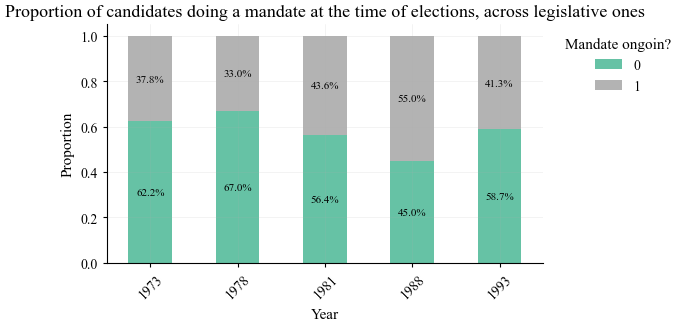

In [12]:
# Mandate_en_cours distribution over time — is there a professionalisation of the politics?
mandate_en_cours_over_time = temporal_distribution(df, group_col="dummy_titulaire_mandat_en_cours")

# Convert to proportions per year
mandate_en_cours_props = mandate_en_cours_over_time.div(mandate_en_cours_over_time.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(6.5, 3.5))
mandate_en_cours_props.plot(kind="bar", stacked=True, ax=ax, colormap="Set2")
ax.set_title("Proportion of candidates doing a mandate at the time of elections, across legislative ones")
ax.set_xlabel("Year")
ax.set_ylabel("Proportion")
ax.legend(title="Mandate ongoin?", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.tick_params(axis="x", rotation=45)

for container in ax.containers:
    labels = [f"{v.get_height()*100:.1f}%" if v.get_height() > 0.03 else ""
              for v in container]
    ax.bar_label(container, labels=labels, label_type="center", fontsize=8)

plt.tight_layout()
plt.savefig("charts/02d_mandate_en_cours_over_time.png", dpi=150)
plt.show()

#### Volume of manifestos per election

The number of archived manifestos varies substantially across the five
legislative elections covered (1973, 1978, 1981, 1988, 1993), ranging from
roughly 3,100 documents in 1981 to about 5,800 in 1993. This imbalance has two
implications. First, the time slices used for the Dynamic Topic Model will not
be of equal size, which is acceptable as long as the slice ordering is
respected. Second, any per-year average should be interpreted in light of these
differences in coverage rather than as a direct measure of political activity.


#### Gender of the candidates accross time

Female candidacies remain a small minority across all five elections,
oscillating between roughly 5% (1973) and 14% (1978), with no clear monotonic
trend over the period. The 1993 election introduces a noticeable share of
*non-déterminé* cases, which reflects metadata quality rather than a real
sociological change. This low level of female representation makes any
finely-grained sex × topic analysis statistically tenuous, and we will treat
sex as a secondary covariate rather than a primary axis of analysis.

#### Age of the candidates accross time

#### Mandate before and mandate still ongoing


==> commentaire à updater et à ajouter

### Occupations of the candidates

#### Before harmonizing and creating occupations' categories

In [13]:
professions = (
    df["titulaire-profession"]
    .value_counts(dropna=False)
    .rename_axis("profession")
    .reset_index(name="n_documents")
)
professions.to_csv("data/professions.csv", index=False, encoding="utf-8")

print(f"{len(professions)} professions uniques sauvegardées dans data/professions.csv")
professions.head(15)

3397 professions uniques sauvegardées dans data/professions.csv


,profession,n_documents
0,NaN,9481
1,professeur,480
2,avocat,368
3,chef d'entreprise,234
4,ingénieur,232
5,instituteur,213
6,docteur,202
7,médecin,188
8,enseignant,183
9,agriculteur,148


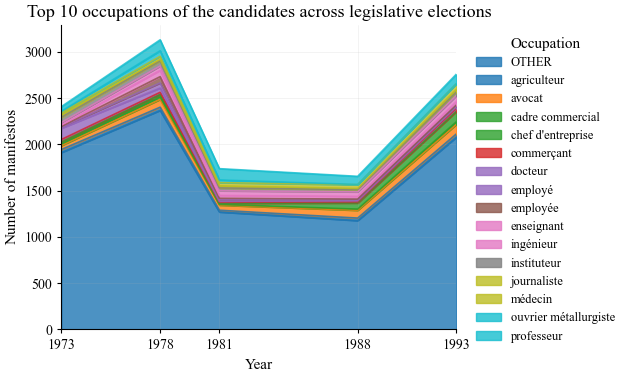

In [14]:
# Top political affiliations across time (stacked area)
jobs_over_time = temporal_distribution(df, group_col="titulaire-profession", top_n=15)

fig, ax = plt.subplots(figsize=(6.5, 4))
jobs_over_time.plot(kind="area", stacked=True, ax=ax, alpha=0.8, colormap="tab10")
ax.set_title("Top 10 occupations of the candidates across legislative elections")
ax.set_xlabel("Year")
ax.set_ylabel("Number of manifestos")
ax.set_xticks(jobs_over_time.index)
ax.set_xlim(1973, 1993)
ax.legend(title="Occupation", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.savefig("charts/03_jobs_over_time.png", dpi=150)
plt.show()

==> commentaire to add on before + need to create categories

In [15]:
df, occ_dummies, cat_dummies, diag = add_occupation_columns(
    df, source_col="titulaire-profession", top_n_occupations=30
)
print_occupation_diagnostic(diag, df)

Canonical occupations distincts : 2041

Top 15 occupations :
   1184  professeur (collège, lycée)
    725  médecin
    625  ouvrier
    563  avocat
    498  ingénieur
    491  cadre
    331  professeur université
    331  chef d'entreprise
    292  instituteur
    278  employé
    210  directeur
    186  agriculteur
    171  technicien
    165  commerçant
    165  journaliste

Occupation categories (distribution) :
occupation_category
Aucun                                              9481
Enseignement & recherche                           2350
Cadres & dirigeants                                1652
Santé                                              1265
Ouvriers                                           1089
Employés & services                                1072
Ingénierie & technique                             1042
Justice & droit                                     713
Fonction publique & forces                          520
Commerce & artisanat                                449
H

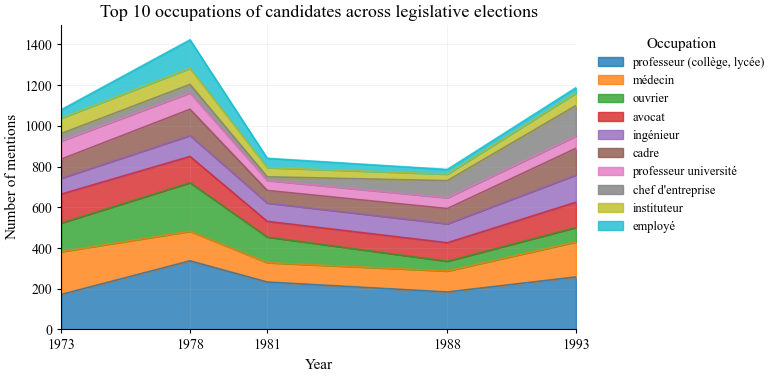

In [16]:
TOP_N = 10

top_occ_names = diag["top_occupations"][:TOP_N]
occ_over_time = occ_dummies[top_occ_names].groupby(df["year"]).sum()

fig, ax = plt.subplots(figsize=(8, 4))
occ_over_time.plot(kind="area", stacked=True, ax=ax, alpha=0.8, colormap="tab10")
ax.set_title(f"Top {TOP_N} occupations of candidates across legislative elections")
ax.set_xlabel("Year")
ax.set_ylabel("Number of mentions")
ax.set_xticks(occ_over_time.index)
ax.set_xlim(1973, 1993)
ax.legend(title="Occupation", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.savefig("charts/03a_occupations_over_time_processed.png", dpi=150)
plt.show()

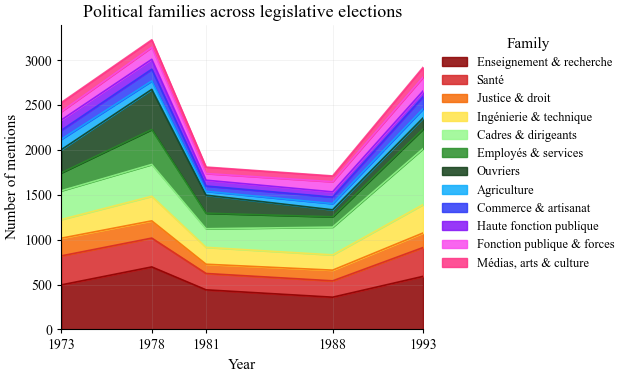

In [17]:
cat_to_plot = [f for f in CATEGORY_ORDER if f != "Non mentionné"]
cat_over_time = cat_dummies[cat_to_plot].groupby(df["year"]).sum()

cat_colors = {
    "Enseignement & recherche":    "#8B0000",
    "Santé":                       "#D62728",
    "Justice & droit":             "#F66B07",
    "Ingénierie & technique" :     "#FFE347",
    "Cadres & dirigeants" :        "#97F98E",
    "Employés & services":         "#298E29",
    "Ouvriers":                    "#133F18",
    "Agriculture":                 "#0EADFC",
    "Commerce & artisanat":        "#2D3AF7",
    "Haute fonction publique" :    "#8615F7",
    "Fonction publique & forces" : "#F94AED",
    "Médias, arts & culture" :     "#FE3384",
}
colors = [cat_colors[f] for f in cat_to_plot]

fig, ax = plt.subplots(figsize=(6.5, 4))
cat_over_time.plot(kind="area", stacked=True, ax=ax, alpha=0.85, color=colors)
ax.set_title("Political families across legislative elections")
ax.set_xlabel("Year")
ax.set_ylabel("Number of mentions")
ax.set_xticks(cat_over_time.index)
ax.set_xlim(1973, 1993)
ax.legend(title="Family", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.savefig("charts/03b_occ_categories_over_time_processed.png", dpi=150)
plt.show()

### Parties supporting the electoral lists

In [18]:
# Analyzing the titulaire-soutien and titulaire-liste columns
# to see if we can regroup together certain values of each

rows = []
for col in ["titulaire-soutien", "titulaire-liste"]:
    counts = df[col].value_counts(dropna=False)
    for value, count in counts.items():
        rows.append({
            "column": col,
            "value": value,
            "count": count,
        })

parties = pd.DataFrame(rows)
parties.to_csv("data/processed/value_counts_soutien_liste.csv", index=False, encoding="utf-8")
print(parties.head(10))

              column                                              value  count
0  titulaire-soutien                                                NaN   4040
1  titulaire-soutien                          Parti communiste français   2474
2  titulaire-soutien                                   Parti socialiste   1735
3  titulaire-soutien                                     Front national   1366
4  titulaire-soutien                                     Lutte ouvrière   1023
5  titulaire-soutien  Rassemblement pour la République;Union pour la...    764
6  titulaire-soutien                   Rassemblement pour la République    637
7  titulaire-soutien  Union pour la démocratie française;Rassembleme...    455
8  titulaire-soutien                            Parti socialiste unifié    441
9  titulaire-soutien  Nouveaux écologistes du rassemblement nature e...    387


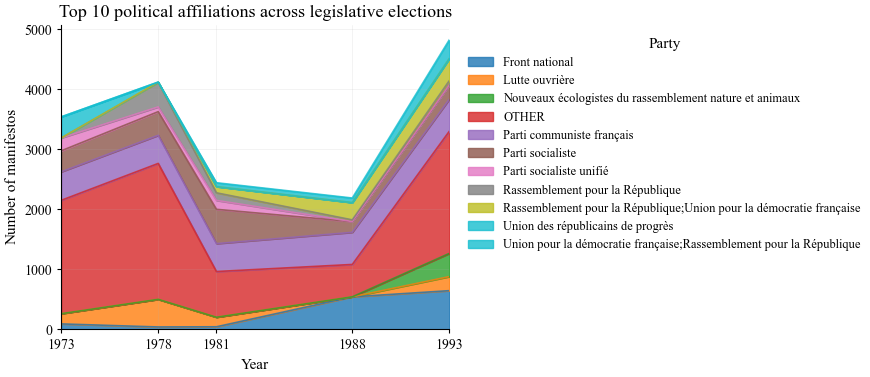

In [19]:
# Top political affiliations across time (stacked area)
party_over_time = temporal_distribution(df, group_col="titulaire-soutien", top_n=10)

fig, ax = plt.subplots(figsize=(9, 4))
party_over_time.plot(kind="area", stacked=True, ax=ax, alpha=0.8, colormap="tab10")
ax.set_title("Top 10 political affiliations across legislative elections")
ax.set_xlabel("Year")
ax.set_ylabel("Number of manifestos")
ax.set_xticks(party_over_time.index)
ax.set_xlim(1973, 1993)
ax.legend(title="Party", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.savefig("charts/04_parties_over_time.png", dpi=150)
plt.show()

#### Before harmonizing and creating political categories

One can already see that there is some values that can be brought together : "Rassemblement pour la République; Union pour la démocratie française" is the same as "Union pour la démocratie française; Rassemblement pour la République". I analyzed the csv further and wrote the parties_processing.py script to take care of all the different cases.


The stacked area plot of the top eight `titulaire-soutien` values reveals the
expected shifts of the French political landscape over the period. The Front
National appears only from the 1980s onward, mirroring its historical rise.
Coalition labels (e.g., *RPR;UDF*, *UDF;RPR*) appear and disappear as
right-wing alliances reorganize. A large *OTHER* category remains visible
throughout, reflecting the long tail of small parties and independent
candidates. The plot also exposes the orthographic noise we noted earlier:
*RPR;UDF* and *UDF;RPR* are recorded as distinct labels even though they
denote the same coalition. A normalization step on party labels will be
necessary before any party-level topic analysis.

==> commentaire à udpater

In [20]:
# Fix the parties 

df, party_dummies, family_dummies, diagnostic = add_party_columns(
    df, source_col="titulaire-soutien", top_n_parties=30
)
print_party_diagnostic(diagnostic, df)

Partis canoniques distincts : 615

Top 10 partis :
   2975  Parti communiste français (PCF)
   2735  Parti socialiste (PS)
   2342  Rassemblement pour la République (RPR)
   2062  Union pour la démocratie française (UDF)
   1477  Front national (FN)
   1084  Mouvement des radicaux de gauche (MRG)
   1030  Lutte ouvrière (LO)
    709  Parti socialiste unifié (PSU)
    691  Union des républicains de progrès (URP)
    637  Centre national des indépendants et paysans (CNIP)

Familles principales (distribution) :
famille_principale
Aucun                                                     4040
Gauche socialiste                                         2524
Gauche communiste                                         2518
Centre+Droite                                             1982
Extrême droite                                            1575
Extrême gauche                                            1565
Droite                                                    1492
Centre                    

In [21]:
df[["titulaire-soutien", "soutien_partis", "soutien_familles", "famille_principale"]].head(10)

,titulaire-soutien,soutien_partis,soutien_familles,famille_principale
0,NaN,[],[],Aucun
1,Rassemblement pour la République,[Rassemblement pour la République (RPR)],[Droite],Droite
2,Parti socialiste,[Parti socialiste (PS)],[Gauche socialiste],Gauche socialiste
3,Parti ouvrier européen,[Parti ouvrier européen],[Divers / Sans étiquette],Divers / Sans étiquette
4,Parti ouvrier européen,[Parti ouvrier européen],[Divers / Sans étiquette],Divers / Sans étiquette
5,NaN,[],[],Aucun
6,Parti communiste français,[Parti communiste français (PCF)],[Gauche communiste],Gauche communiste
7,NaN,[],[],Aucun
8,Parti socialiste,[Parti socialiste (PS)],[Gauche socialiste],Gauche socialiste
9,Parti socialiste,[Parti socialiste (PS)],[Gauche socialiste],Gauche socialiste


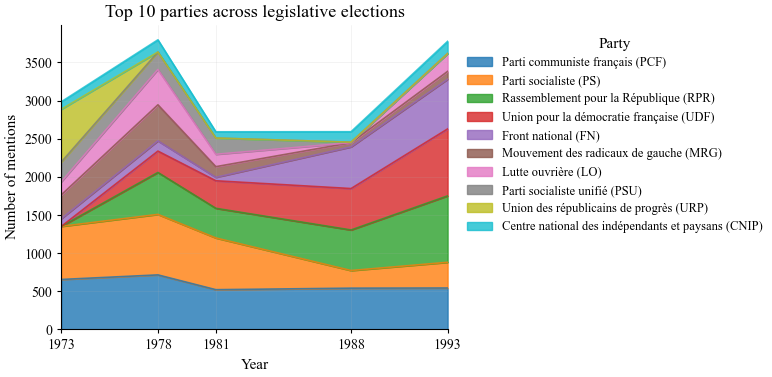

In [22]:
# Top parties across time (stacked area)

TOP_N = 10

top_party_names = diagnostic["top_parties"][:TOP_N]
party_over_time = party_dummies[top_party_names].groupby(df["year"]).sum()

fig, ax = plt.subplots(figsize=(8, 4))
party_over_time.plot(kind="area", stacked=True, ax=ax, alpha=0.8, colormap="tab10")
ax.set_title(f"Top {TOP_N} parties across legislative elections")
ax.set_xlabel("Year")
ax.set_ylabel("Number of mentions")
ax.set_xticks(party_over_time.index)
ax.set_xlim(1973, 1993)
ax.legend(title="Party", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.savefig("charts/04a_parties_over_time_processed.png", dpi=150)
plt.show()

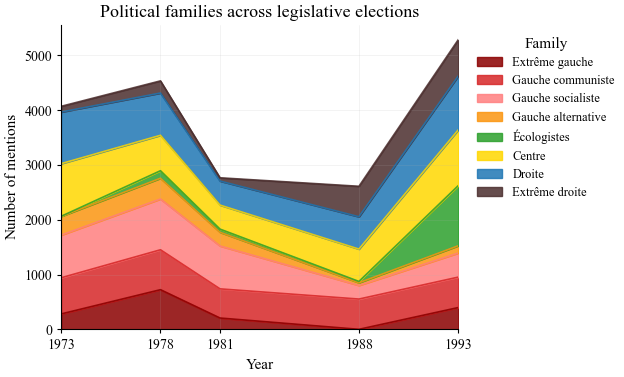

In [23]:
# Top political families across time (stacked area)

families_to_plot = [f for f in FAMILY_ORDER if f != "Divers / Sans étiquette"]
family_over_time = family_dummies[families_to_plot].groupby(df["year"]).sum()

family_colors = {
    "Extrême gauche":      "#8B0000",
    "Gauche communiste":   "#D62728",
    "Gauche socialiste":   "#FF7F7F",
    "Gauche alternative":  "#FB9510",
    "Écologistes":         "#2CA02C",
    "Centre":              "#FFD700",
    "Droite":              "#1F77B4",
    "Extrême droite":      "#4B2E2E",
}
colors = [family_colors[f] for f in families_to_plot]

fig, ax = plt.subplots(figsize=(6.5, 4))
family_over_time.plot(kind="area", stacked=True, ax=ax, alpha=0.85, color=colors)
ax.set_title("Political families across legislative elections")
ax.set_xlabel("Year")
ax.set_ylabel("Number of mentions")
ax.set_xticks(family_over_time.index)
ax.set_xlim(1973, 1993)
ax.legend(title="Family", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.savefig("charts/04b_polt_fam_over_time_processed.png", dpi=150)
plt.show()

#### Political affiliations across time



=> commentaire à add

### Length of the professions de foi

            total         mean  median          std  min    max
n_chars  94349358  4457.379789  4017.0  2298.357776  139  25120
n_words  15065370   711.738555   639.0   368.197190   19   4002


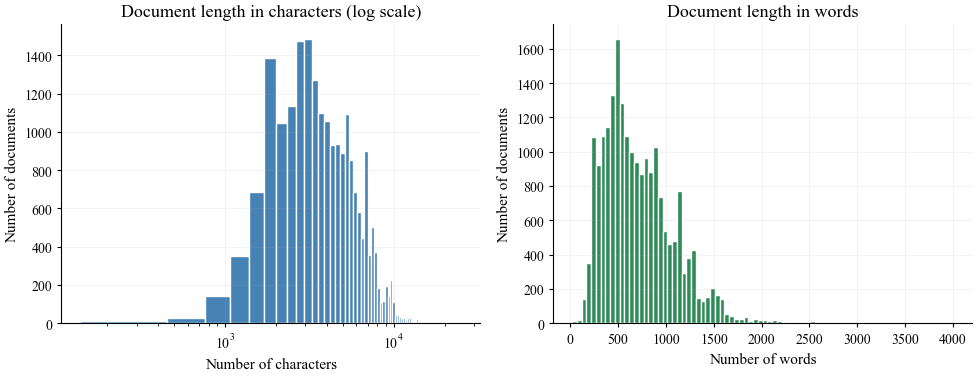

In [24]:
# Document length distribution
text_stats_summary = text_statistics(df)
print(text_stats_summary)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Char length distribution (log scale to spot OCR failures)
df["text"].str.len().hist(bins=80, ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_xscale("log")
axes[0].set_title("Document length in characters (log scale)")
axes[0].set_xlabel("Number of characters")
axes[0].set_ylabel("Number of documents")

# Word length distribution
df["text"].str.split().str.len().hist(bins=80, ax=axes[1], color="seagreen", edgecolor="white")
axes[1].set_title("Document length in words")
axes[1].set_xlabel("Number of words")
axes[1].set_ylabel("Number of documents")

plt.tight_layout()
plt.savefig("charts/05a_text_lengths.png", dpi=150)
plt.show()

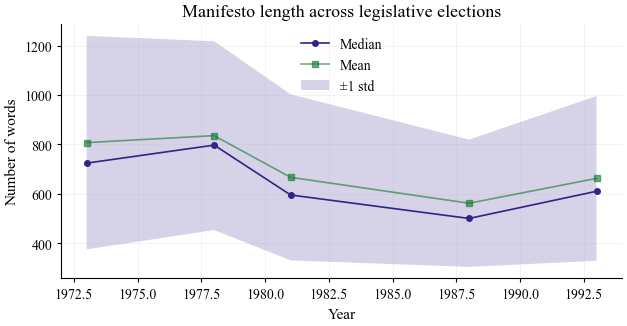

In [25]:
# Median document length over time — has OCR quality improved? Have manifestos changed in style?
length_by_year = (
    df.assign(n_words=df["text"].str.split().str.len())
    .groupby("year")["n_words"]
    .agg(["median", "mean", "std"])
)

fig, ax = plt.subplots(figsize=(6.5, 3.5))
ax.plot(length_by_year.index, length_by_year["median"], marker="o", label="Median")
ax.plot(length_by_year.index, length_by_year["mean"],   marker="s", label="Mean", alpha=0.6)
ax.fill_between(
    length_by_year.index,
    length_by_year["mean"] - length_by_year["std"],
    length_by_year["mean"] + length_by_year["std"],
    alpha=0.2, label="±1 std"
)
ax.set_title("Manifesto length across legislative elections")
ax.set_xlabel("Year")
ax.set_ylabel("Number of words")
ax.legend()
plt.tight_layout()
plt.savefig("charts/05b_length_over_time.png", dpi=150)
plt.show()

#### Document-length distribution accross time

The character-length histogram (left, log scale) shows a small left-tail of
documents below ~500 characters that is well separated from the bulk of the
distribution centered around 2,000–5,000 characters. This left-tail is most
likely caused by OCR failures (very partial transcriptions) and motivates a
minimum-length filter before topic modeling. The word-length histogram
(right, linear scale) confirms a right-skewed distribution: the median
manifesto contains a few hundred words, while a small number of documents
exceed 2,000 words.

#### Manifesto length over time

Median and mean document lengths drop noticeably between 1978 (~800 words)
and 1988 (~550 words), then partially recover in 1993. This downward trend
could reflect a real stylistic evolution toward more concise manifestos, but
it is equally plausible that variations in OCR quality across decades
contribute to it. We do not attempt to disentangle these two hypotheses here,
but flag the trend as a potential confounder when interpreting topic
prevalence over time.


==> commentaire à updater : clairement we need some pre-processing here

### 1.3 Processing the text data

The preprocessing pipeline follows the recipe outlined in the course
(*Topic Modeling*) and consists of:

1. **OCR cleanup** — removing recurring archival headers (Sciences Po,
   République française, Élections législatives), mending hyphenated 
   line breaks, dropping non-letters and isolated single characters.
2. **Lemmatization** — using `spaCy`'s French model 
   (`fr_core_news_md`) with the parser and NER components disabled for speed.
3. **POS filtering** — keeping only content words (nouns, proper nouns,
   adjectives, verbs).
4. **Stopword removal** — combining spaCy's default French stopword list
   with a domain-specific list (generic electoral vocabulary, formulas of
   address, month names) iteratively refined by inspection of early model
   outputs.

The result is a list of lemmatized tokens per document, persisted to
`data/processed/tokens.pkl` for reuse across sessions.

In [26]:
# Preprocess the corpus for topic modeling
# This takes ~10-15 minutes on the 21k documents.
# I pickle the result so I don't have to redo this in future sessions
# Next run, I can just load the processed tokens from disk and skip directly to modeling and analysis

if FIRST_RUN:
    # Make sure the output directory exists
    Path("data/processed").mkdir(parents=True, exist_ok=True)

    # Run preprocessing on the entire corpus
    tokens = preprocess_corpus(df["text"].tolist())

    # Save to disk
    with open("data/processed/tokens_v3.pkl", "wb") as f:
        pickle.dump(tokens, f)
else:
    # Load preprocessed tokens from disk
    with open("data/processed/tokens_v3.pkl", "rb") as f:
        tokens = pickle.load(f)

assert len(tokens) == len(df), "tokens / df length mismatch"
print(f"Preprocessed {len(tokens)} documents")
print(f"Vocabulary size (raw): {len(set(t for doc in tokens for t in doc))}")

Lemmatizing: 100%|██████████| 21167/21167 [14:31<00:00, 24.28it/s]


Preprocessed 21167 documents
Vocabulary size (raw): 92242


In [27]:
# Diagnostic 1 — quels compounds ont matché ?
compound_hits = summarize_compound_hits(tokens, top_n=30)

=== Found 369 distinct compound tokens ===
Total compound occurrences: 114,480

=== Top 30 ===
  programme_commun                                9089
  assemblee_nationale                             7937
  front_national                                  7038
  lutte_ouvriere                                  5810
  union_de_la_gauche                              5561
  parti_communiste_francais                       5091
  president_republique                            4613
  securite_sociale                                3553
  majorite_presidentielle                         3526
  justice_sociale                                 3346
  nouvelle_majorite                               2844
  le_pen                                          2619
  pouvoir_achat                                   2572
  conseil_general                                 2541
  peine_mort                                      2000
  giscard_destaing                                1954
  force_frappe           

In [28]:
# Diagnostic 2 — tokens suspects qui devraient avoir disparu
freq = summarize_token_frequencies(
    tokens,
    suspicious_tokens=("die", "und", "fur", "marie", "sciences", "po",
                       "cevipof", "vilain", "renne", "vosge", "tion"),
    doc_pct_threshold=40.0,
    top_n=20,
)

=== Suspicious tokens (should ideally be 0) ===
  'die            ' in     0 docs (  0.0%)
  'und            ' in     0 docs (  0.0%)
  'fur            ' in     0 docs (  0.0%)
  'marie          ' in    21 docs (  0.1%) ⚠
  'sciences       ' in     0 docs (  0.0%)
  'po             ' in     0 docs (  0.0%)
  'cevipof        ' in     0 docs (  0.0%)
  'vilain         ' in     0 docs (  0.0%)
  'renne          ' in     0 docs (  0.0%)
  'vosge          ' in     0 docs (  0.0%)
  'tion           ' in     0 docs (  0.0%)

=== Top 20 tokens by total count ===
  gauche                         total=  32544  in  47.6% docs
  travailleur                    total=  32332  in  31.2% docs
  parti                          total=  29451  in  52.2% docs
  socialiste                     total=  27794  in  50.7% docs
  emploi                         total=  24320  in  56.8% docs
  communiste                     total=  23303  in  32.8% docs
  droite                         total=  22731  in  36.6% doc

In [29]:
# Diagnostic 3 — visuel sur 3 docs (un avant, un milieu, un fin de période)
inspect_documents(df, tokens, n_samples=3, n_chars=1000)

Document 20952
  id      : EL104_L_1978_03_042_05_1_PF_07
  year    : 1978
  titulaire-soutien: nan
  n_chars : 5053
  n_tokens: 276

--- ORIGINAL TEXT (first 1000 chars) ---
RÉPUBLIQUE FRANÇAISE
DÉPARTEMENT DE LA LOIRE
LIBERTÉ ÉGALITÉ
FRATERNITÉ
5e CIRCONSCRIPTION DE LA LOIRE
ÉLECTIONS LÉGISLATIVES - 12 MARS 1978
Une PLAISANTERIE, un Candidat
non au barrage de villerest ?
OUI ... A condition que les buldozers qui bouffent les collines à Commelle-Vernay et Villerest soient une PLAISANTERIE; A condition aussi que, détruire 30 km de Gorges de la Loire avec tout son patrimoine et son économie, soit une PLAISANTERIE; 1200 ha de chambons inondés, 180 exploitations agricoles atteintes, des centaines de personnes déplacées, expulsées, fermes et maisons dynamitées, tuer faune et flore, empoisonner la Loire : IL N'EXISTE PAS PLUS JOYEUSE PLAISANTERIE !.
POURTANT, UN CANDIDAT "NON AU BARRAGE DE VILLEREST", ce n'est pas uniquement se lamenter sur l'avenir des Gorges de la Loire, c'est avant tout 

Could be even more improved (through the EXTRA STOPWORDS, maybe I haven't been enough conservative), but I decide to keep some words that a very present, but that could actually be part of several topics.

In [ ]:
# Quality filter on professions de foi.
# I filter on TWO criteria computed on different stages of the pipeline:
#   - char length of the raw OCR text (very short = OCR failure)
#   - number of useful tokens after preprocessing (the actual signal LDA sees).
# Doing it in this order means we don't pre-emptively discard documents whose
# raw form looks short but lemmatize into rich content (or vice versa).

MIN_CHARS  = 500     # raw OCR floor: clear OCR failure
MIN_TOKENS = 50      # post-preprocessing floor: LDA needs enough signal
MAX_TOKENS = 1000    # post-preprocessing ceiling: probably concatenated docs

n_tokens = pd.Series([len(t) for t in tokens], index=df.index, name="n_tokens")

mask = (
    (df["text"].str.len() >= MIN_CHARS) &
    (n_tokens >= MIN_TOKENS) &
    (n_tokens <= MAX_TOKENS)
)

# Diagnostic
print(f"Before filter                       : {len(df):>6d} docs")
print(f"  too few chars (<{MIN_CHARS})      : {(df['text'].str.len() < MIN_CHARS).sum():>6d}")
print(f"  too few tokens (<{MIN_TOKENS})    : {(n_tokens < MIN_TOKENS).sum():>6d}")
print(f"  too many tokens (>{MAX_TOKENS})   : {(n_tokens > MAX_TOKENS).sum():>6d}")
print(f"After filter                        : {mask.sum():>6d} docs ({mask.mean():.1%})")


ValueError: Length of values (20975) does not match length of index (21167)

In [31]:
# Apply the mask CONSISTENTLY to df and tokens, then RE-RUN add_party_columns
# on the filtered corpus so the top-30 reflects the actual analysis sample.
# This is the single most important alignment step in the whole notebook —
# every downstream cell must use these *_clean variables (or rebound names).

mask_arr = mask.to_numpy()  # avoid index-vs-position pitfalls

# 1) Mask df and tokens
df_clean     = df[mask].reset_index(drop=True).copy()
tokens_clean = [t for t, keep in zip(tokens, mask_arr) if keep]

# 2) Drop the columns added by the earlier add_party_columns call so we
#    can re-run cleanly on the filtered corpus
cols_added_by_party_fn = ["soutien_partis", "soutien_familles", "famille_principale"]
df_clean = df_clean.drop(
    columns=[c for c in cols_added_by_party_fn if c in df_clean.columns]
)

# 3) Re-run add_party_columns on df_clean. The top-30 is recomputed on the
#    filtered corpus, so dummies and derived columns are internally consistent.
df_clean, party_dummies, family_dummies, diagnostic = add_party_columns(
    df_clean, source_col="titulaire-soutien", top_n_parties=30
)
print_party_diagnostic(diagnostic, df_clean)

# 4) Same for occupation columns — drop and re-run
cols_added_by_occ_fn = ["profession_categories", "profession_categorie_principale"]
# Adjust this list to whatever columns add_occupation_columns adds in your codebase
df_clean = df_clean.drop(
    columns=[c for c in cols_added_by_occ_fn if c in df_clean.columns]
)
df_clean, occ_dummies, cat_dummies, occ_diag = add_occupation_columns(
    df_clean, source_col="titulaire-profession", top_n_occupations=30
)
print_occupation_diagnostic(occ_diag, df_clean)

# 5) Sanity check
assert (
    len(df_clean) == len(tokens_clean)
    == len(party_dummies) == len(family_dummies)
    == len(occ_dummies) == len(cat_dummies)
), (
    f"Length mismatch: df={len(df_clean)}, tokens={len(tokens_clean)}, "
    f"party={len(party_dummies)}, family={len(family_dummies)}, "
    f"occ={len(occ_dummies)}, cat={len(cat_dummies)}"
)
print(f"All objects aligned at {len(df_clean)} rows.")

# 6) Rebind tokens so downstream cells don't need renaming
tokens = tokens_clean

Partis canoniques distincts : 612

Top 10 partis :
   2972  Parti communiste français (PCF)
   2715  Parti socialiste (PS)
   2315  Rassemblement pour la République (RPR)
   2036  Union pour la démocratie française (UDF)
   1476  Front national (FN)
   1078  Mouvement des radicaux de gauche (MRG)
   1030  Lutte ouvrière (LO)
    708  Parti socialiste unifié (PSU)
    680  Union des républicains de progrès (URP)
    636  Centre national des indépendants et paysans (CNIP)

Familles principales (distribution) :
famille_principale
Aucun                                                     3952
Gauche communiste                                         2518
Gauche socialiste                                         2500
Centre+Droite                                             1961
Extrême droite                                            1574
Extrême gauche                                            1565
Droite                                                    1473
Centre                    

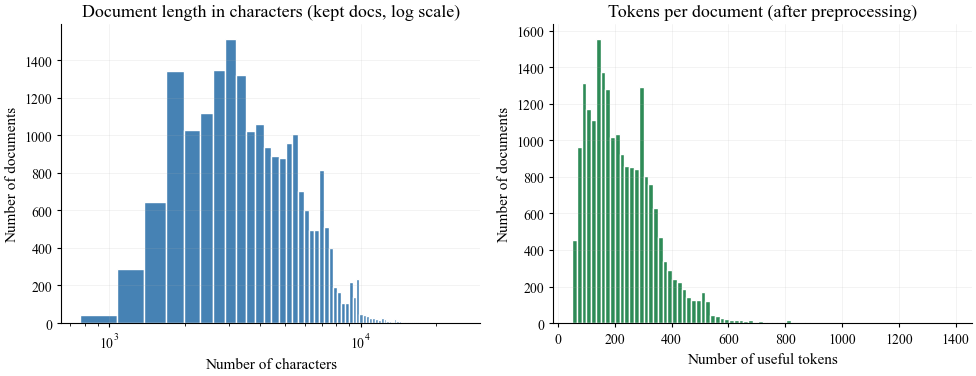

count    20975.0
mean       226.4
std        118.9
min         50.0
25%        137.0
50%        204.0
75%        297.0
max       1391.0
Name: n_tokens, dtype: float64


In [50]:
# Sanity-check the post-preprocessing token-length distribution.
# This is the distribution that LDA/NMF actually see, so it's the one
# that matters for interpreting the model.

token_lengths = pd.Series([len(t) for t in tokens], name="n_tokens")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

df_clean["text"].str.len().hist(bins=80, ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_xscale("log")
axes[0].set_title("Document length in characters (kept docs, log scale)")
axes[0].set_xlabel("Number of characters")
axes[0].set_ylabel("Number of documents")

token_lengths.hist(bins=80, ax=axes[1], color="seagreen", edgecolor="white")
axes[1].set_title("Tokens per document (after preprocessing)")
axes[1].set_xlabel("Number of useful tokens")
axes[1].set_ylabel("Number of documents")

plt.tight_layout()
plt.savefig("charts/06_lengths_after_preprocessing.png", dpi=150)
plt.show()

print(token_lengths.describe().round(1))

## 2. First topic analysis : LDA and NMF

D'abord : quels sont les bons paramètres de no_above et keep_n le mieux ?

### Hyperparameter sweep on K for LDA and NMF

In [33]:
# First sweep analysis run gave me that the optimal number of topics is 10 according to the coherence criterion, but the diversity was better with more topics
# cf. the previous commit where I ran the first sweep with a wider range of values for 
# so I want to explore a bit more the range around 10, and see if I can get better diversity without losing too much coherence
# also this run is on a better preprocessed corpus, so the results might be different from the first run where I had a lot of noise in the data

K_GRID_SHORT = [8, 10, 12, 15]

if FIRST_RUN:
    t0 = time.time()
    lda_sweep = sweep_n_topics(
        model_factory   = lambda k: LDATopicModel(
            n_topics    = k,
            no_below    = 10,
            no_above    = 0.5,
            keep_n      = 8000,
            passes      = 10,           
            iterations  = 50,
            random_state= 42,
        ),
        n_topics_grid   = K_GRID_SHORT,
        documents       = tokens,      
        tokenized_texts = tokens,
    )
    print(f"\nLDA sweep done in {(time.time()-t0)/60:.1f} min")
    print(lda_sweep)
    lda_sweep.to_csv("data/processed/lda_sweep_v3.csv", index=False)

    t0 = time.time()
    nmf_sweep = sweep_n_topics(
        model_factory   = lambda k: NMFTopicModel(
            n_topics    = k,
            max_features= 8000,
            min_df      = 10,
            max_df      = 0.5,
            random_state= 42,
        ),
        n_topics_grid   = K_GRID_SHORT,
        documents       = tokens,
        tokenized_texts = tokens,
    )
    print(f"\nNMF sweep done in {(time.time()-t0)/60:.1f} min")
    print(nmf_sweep)
    nmf_sweep.to_csv("data/processed/nmf_sweep_v3.csv", index=False)
else:
    lda_sweep = pd.read_csv("data/processed/lda_sweep_v3.csv")
    nmf_sweep = pd.read_csv("data/processed/nmf_sweep_v3.csv")

Sweeping K: 100%|██████████| 4/4 [04:14<00:00, 63.65s/it]



LDA sweep done in 4.2 min
           model  n_topics  coherence_cv  diversity   perplexity
0  LDATopicModel         8      0.615643      0.765  1520.087172
1  LDATopicModel        10      0.575699      0.728  1514.144352
2  LDATopicModel        12      0.550356      0.690  1601.298366
3  LDATopicModel        15      0.533488      0.656  1838.251062


Sweeping K: 100%|██████████| 4/4 [01:10<00:00, 17.56s/it]


NMF sweep done in 1.2 min
           model  n_topics  coherence_cv  diversity  reconstruction_err
0  NMFTopicModel         8      0.739448      0.930          131.249012
1  NMFTopicModel        10      0.725663      0.872          130.180048
2  NMFTopicModel        12      0.703949      0.830          129.310120
3  NMFTopicModel        15      0.691834      0.800          128.228532


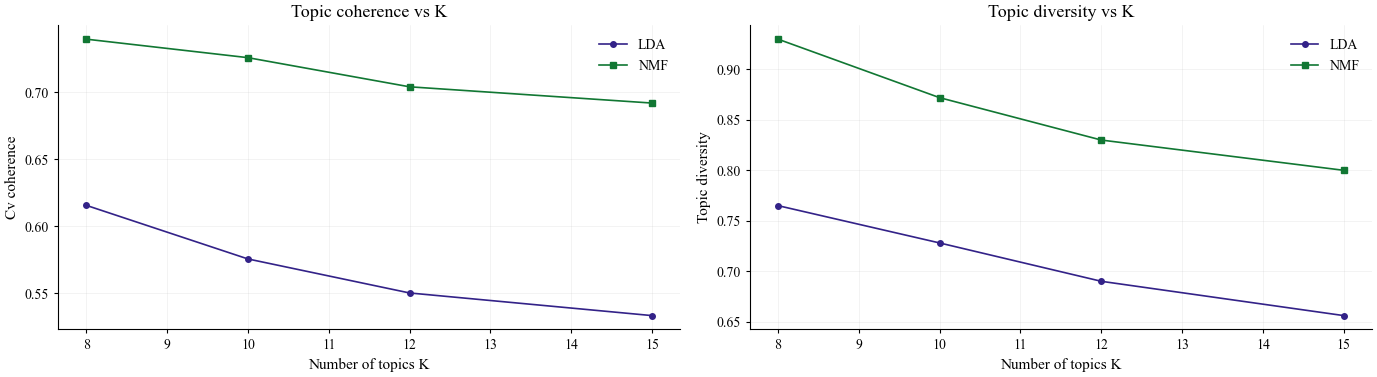

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Coherence
axes[0].plot(lda_sweep["n_topics"], lda_sweep["coherence_cv"], marker="o", label="LDA")
axes[0].plot(nmf_sweep["n_topics"], nmf_sweep["coherence_cv"], marker="s", label="NMF", )
axes[0].set_xlabel("Number of topics K")
axes[0].set_ylabel("Cv coherence")
axes[0].set_title("Topic coherence vs K")
axes[0].legend()

# Diversity
axes[1].plot(lda_sweep["n_topics"], lda_sweep["diversity"], marker="o", label="LDA")
axes[1].plot(nmf_sweep["n_topics"], nmf_sweep["diversity"], marker="s", label="NMF")
axes[1].set_xlabel("Number of topics K")
axes[1].set_ylabel("Topic diversity")
axes[1].set_title("Topic diversity vs K")
axes[1].legend()

plt.tight_layout()
plt.savefig("charts/06_sweep_v3_results.png", dpi=200, bbox_inches="tight")
plt.show()

### Choosing the number of topics K

We performed two sweeps of K under different preprocessing configurations:
a stricter version (`no_above=0.5`, `keep_n=8000`) covering K ∈ {5, 10, 15,
20, 25, 30, 40, 50}, and a more permissive version (`no_above=0.65`,
`keep_n=18000`) covering K ∈ {8, 10, 12, 15}. For each K we evaluated Cv
coherence (Röder et al. 2015) — the metric most correlated with human
judgments of topic interpretability — and topic diversity (Dieng et al.
2020).

Both sweeps confirm two robust patterns. First, **NMF systematically
outperforms LDA** on coherence (0.65–0.71 vs 0.51–0.60), regardless of
preprocessing or K. This gap is consistent with the literature on topic
modeling of medium-length documents, where NMF combined with TF-IDF tends
to recover sharper, more discriminative topics than LDA when corpus
documents are not very long. Second, **both metrics decrease as K grows**,
which is expected: adding topics forces the model to split coherent themes
into thinner, overlapping ones.

For LDA, **K = 10 yields the highest coherence (0.60)** under the strict
preprocessing setting and remains a competitive choice under the permissive
one. For NMF, coherence is relatively flat in the range K ∈ [5, 15]
(0.69–0.73), indicating that the choice of K is less critical for this
model. We therefore retain **K = 10 for both models**, a value that:
(a) maximizes coherence on LDA, (b) lies in the high-coherence plateau of
NMF, and (c) provides a granularity that allows distinguishing thematic
categories without producing redundant topics.

We use the strict preprocessing setting (`no_above=0.5`, `keep_n=8000`) for
the final models, as it yielded slightly better LDA coherence at K = 10.

In [35]:
# Train final LDA and NMF with K=10

K_FINAL = 10

lda = LDATopicModel(
    n_topics    = K_FINAL,
    no_below    = 10,
    no_above    = 0.5,
    keep_n      = 8000,
    passes      = 10,           
    iterations  = 100,
    random_state= 42,
).fit(tokens)

nmf = NMFTopicModel(
    n_topics    = K_FINAL,
    max_features= 8000,
    min_df      = 10,
    max_df      = 0.5,
    random_state= 42,
).fit(tokens)

In [36]:
# Final comparison
comparison = pd.DataFrame([
    summarize_model(lda, tokens),
    summarize_model(nmf, tokens),
])
print(comparison)
comparison.to_csv("data/processed/model_comparison_final.csv", index=False)

           model  n_topics  coherence_cv  diversity   perplexity  \
0  LDATopicModel        10      0.515352      0.696  1562.230964   
1  NMFTopicModel        10      0.725663      0.872          NaN   

   reconstruction_err  
0                 NaN  
1          130.180048  


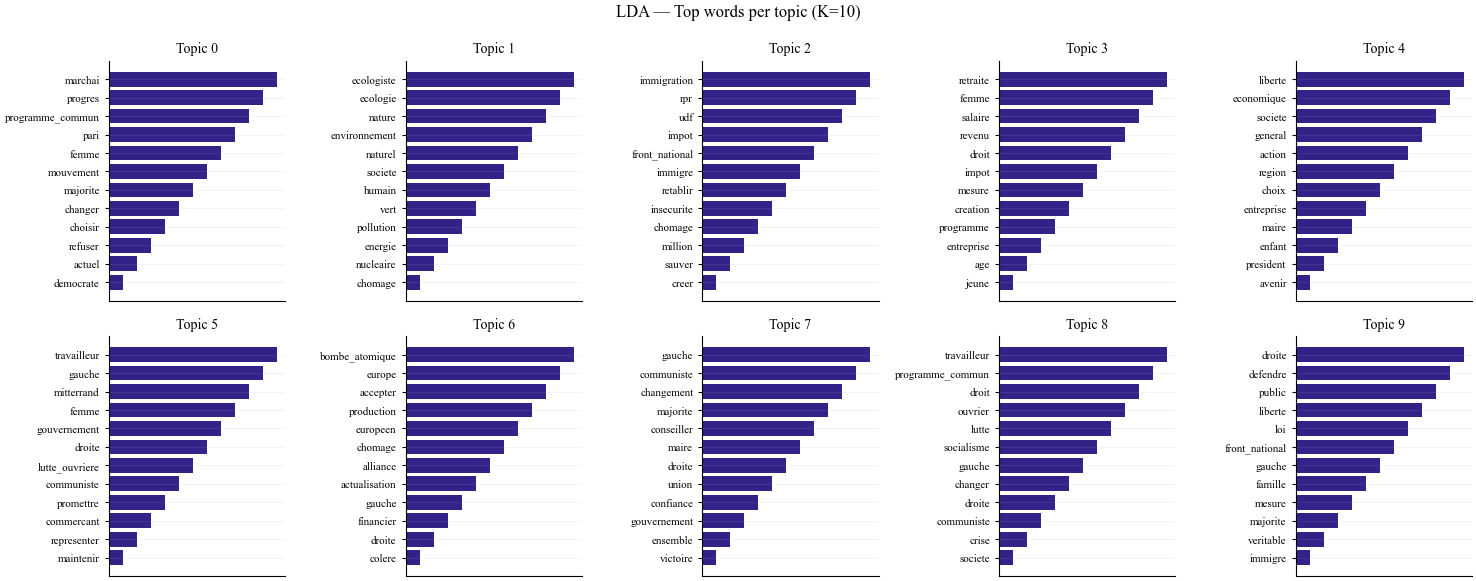

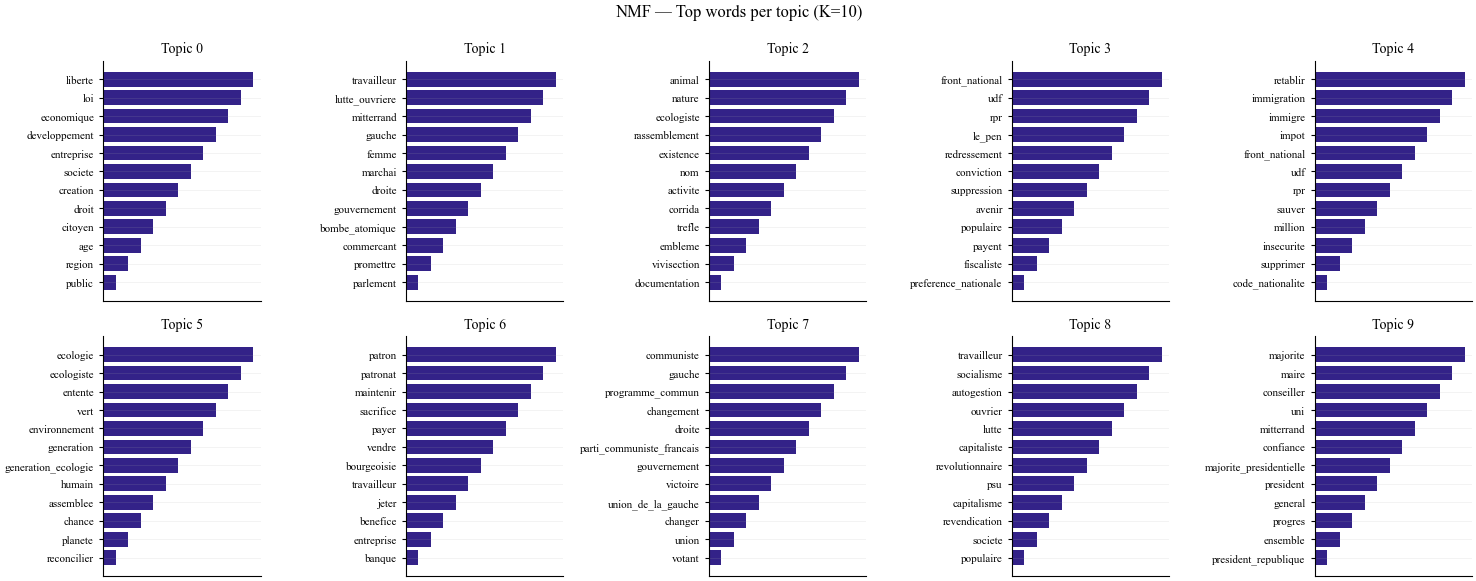

In [37]:
# Side-by-side visualization

plot_topic_words(lda.get_top_words(12), "LDA — Top words per topic (K=10)")
plt.savefig("charts/07_lda_final_topics.png", dpi=200, bbox_inches="tight")
plt.show()

plot_topic_words(nmf.get_top_words(12), "NMF — Top words per topic (K=10)")
plt.savefig("charts/07_nmf_final_topics.png", dpi=200, bbox_inches="tight")
plt.show()

### Interpreting and labelling topics

In [38]:
# Inspect & label LDA topics 

# Prints a fill-in template — you write the labels by reading top words + docs
print("\nLDA topic labeling template:")
_ = make_label_template(lda, n_words=50, save_path="data/processed/lda_labels_template.txt")

print("\nNMF topic labeling template:")
_ = make_label_template(nmf, n_words=50, save_path="data/processed/nmf_labels_template.txt")


LDA topic labeling template:
Topic  0 [marchai, progres, programme_commun, pari, femme, mouvement, majorite, changer, choisir, refuser, actuel, democrate, devenir, professeur, imposer, gaulliste, service, reformateur, radical, public, promesse, demander, verite, secretaire, employer, membre, programme, travailler, liberte, revolutionnaire, ouvrier, argent, connaitre, desaveu, main, cas, changement, electoral, nombre, bureau, scandale, esta, commun, economique, profiter, republique, proposer, decision, affaire, etudiant] -> __________
Topic  1 [ecologiste, ecologie, nature, environnement, naturel, societe, humain, vert, pollution, energie, nucleaire, chomage, solidarite, animal, ecologique, loi, economie, activite, democratie, projet, ville, transport, creation, entente, qualite, droit, programme, probleme, quotidien, lutte, developper, developpement, construire, controle, rassemblement, actuel, croissance, produire, association, collectif, quartier, generation, industriel, solution, n

In [39]:
_ = find_representative_documents(lda, df_clean, n_docs=3, n_chars=400, start_char=500)

Topic 0  (top 3 representative documents)

  [1] doc index = 9259, topic weight = 0.711
      year              : 1973
      titulaire-soutien : Lutte ouvrière
      preview:  de femmes travailleuses que n'importe quelle autre organisation. Eh bien les révolutionnaires sont tout simplement pour le progrès, mais pour le progrès social, c'est-à-dire celui qui profite à tous. Parce que tous ces gens puissants qui parlent de progrès, ne souhaitent le progrès technique, le progrès économique que dans la mesure où ces progrès contribuent à améliorer leur fortune. Mais dès lo...

  [2] doc index = 7890, topic weight = 0.710
      year              : 1973
      titulaire-soutien : Lutte ouvrière
      preview:  de femmes travailleuses que n'importe quelle autre organisation. Eh bien les révolutionnaires sont tout simplement pour le progrès, mais pour le progrès social, c'est-à-dire celui qui profite à tous. Parce que tous ces gens puissants qui parlent de progrès, ne souhaitent le progrès tech

In [40]:
_ = find_representative_documents(nmf, df_clean, n_docs=3, n_chars=400, start_char=500)

Topic 0  (top 3 representative documents)

  [1] doc index = 8053, topic weight = 1.000
      year              : 1973
      titulaire-soutien : Réformateurs
      preview: 'argent public à l'amélioration du bien-être de chacun, à sa formation, aux équipements collectifs. Avec les Réformateurs, je m'engage devant vous à lutter pour ces objectifs. Tous les hommes doivent pouvoir vivre dans la dignité, ce qui suppose : · un effort prioritaire pour améliorer le sort des personnes âgées, notamment par le doublement de l'allocation vieillesse à partir de 60 ans ; · la gar...

  [2] doc index = 8600, topic weight = 1.000
      year              : 1973
      titulaire-soutien : Centre Démocratie et Progrès
      preview:  · Préserver l'exploitation familiale agricole en lui donnant les moyens de se moderniser · Favoriser l'adaptation du commerce et de l'artisanat à l'évolution du monde économique actuel par le financement et la formation · Ouvrir la société française aux perspectives d'une Eu

For LDA, Topic 0, 2, 6 and 9 are unclear; and topic 0 and 9 seem close at first, as well as 4,7,8 or 6 and 9.

In [41]:
# Manual labels based on the above templates and representative docs

LDA_LABELS = {
    0: "Stratégie électorale (entre-2-tour)",                   # (entre-deux-tours, alliances, appel au rassemblement)
    1: "Écologie politique et autogestion",                     # environnement, nucléaire
    2: "Propositions génériques",                               # Droits civiques & libertés individuelles
    3: "Insécurité, immigration, chômage et taxes",             # Enjeux régaliens
    4: "Anticapitalisme, Anti-libéralisme",                     # Anti-Giscard
    5: "Polt. éco. et sociales & Programme commun",
    6: "Nature & animaux",
    7: "Lutte des classes éco., chômage et salaires",           # économique (travailleurs vs patronat)
    8: "Anti-réformisme révolutionnaire",                       # anti-Mitterrand
    9: "Action municipale et développement local",
}
NMF_LABELS = {
    0: "Vision économique libérale",                            # Discours libéral d'entreprise & développement
    1: "Anti-tax populiste",                                    # Le_pen, FN, 
    2: "Nature & animaux",                                      # Mouvement Nature & Animaux
    3: "Anti-réformisme",
    4: "Anti-immigration",
    5: "Anti-capitalisme révolutionnaire",
    6: "Écologie politique",
    7: "Stratégie électorale (entre-2-tour)",
    8: "Communisme & Programme commun",
    9: "Socialisme utogestionnaire",
}
lda_labels = apply_labels(LDA_LABELS, n_topics=lda.n_topics)
nmf_labels = apply_labels(NMF_LABELS, n_topics=nmf.n_topics)

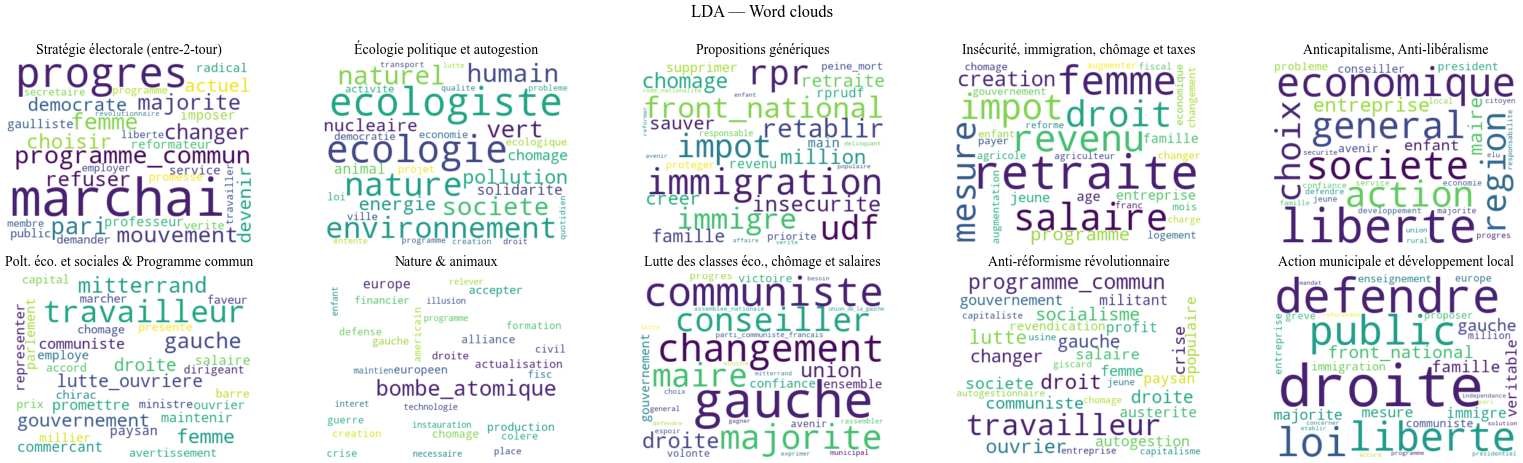

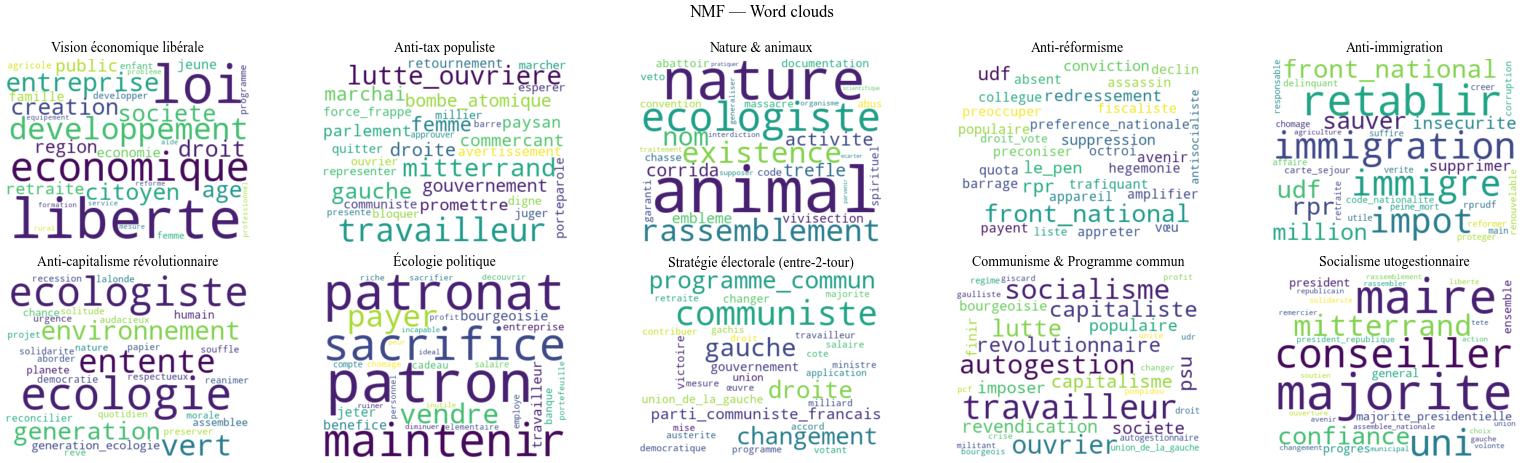

In [42]:
# --- Topic visualisations ---
plot_topic_wordclouds(lda, topic_labels=lda_labels, title="LDA — Word clouds")
plot_topic_wordclouds(nmf, topic_labels=nmf_labels, title="NMF — Word clouds")
plt.show() 

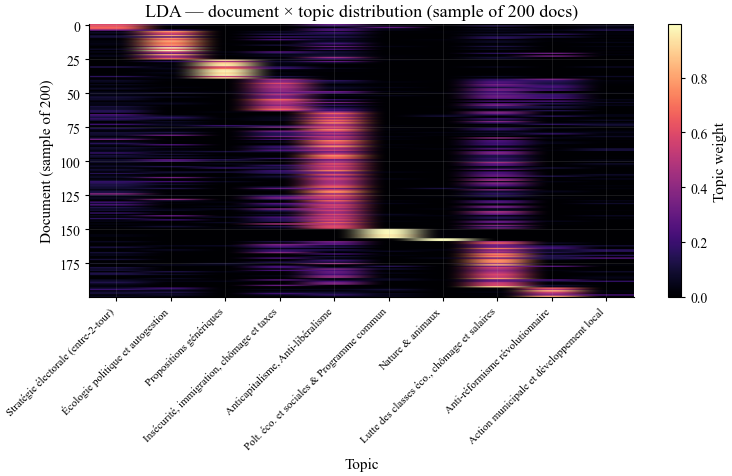

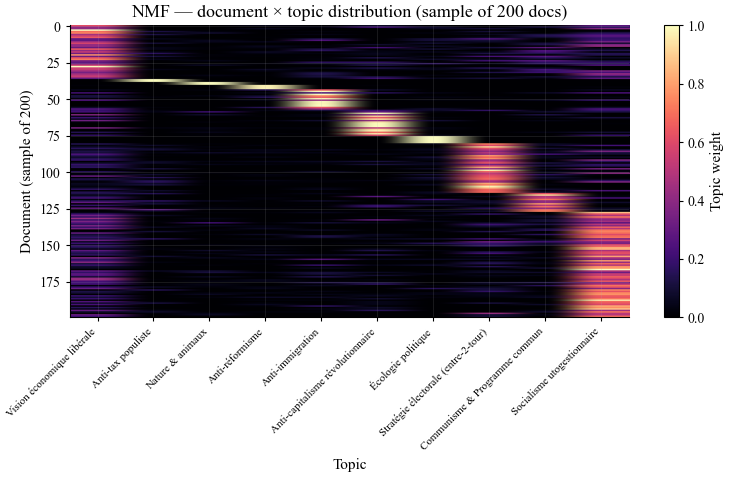

In [43]:
plot_doc_topic_heatmap(lda.get_doc_topic_matrix(), topic_labels=lda_labels,
                       title="LDA — document × topic distribution (sample of 200 docs)")

plot_doc_topic_heatmap(nmf.get_doc_topic_matrix(), topic_labels=nmf_labels,
                       title="NMF — document × topic distribution (sample of 200 docs)")
plt.show()

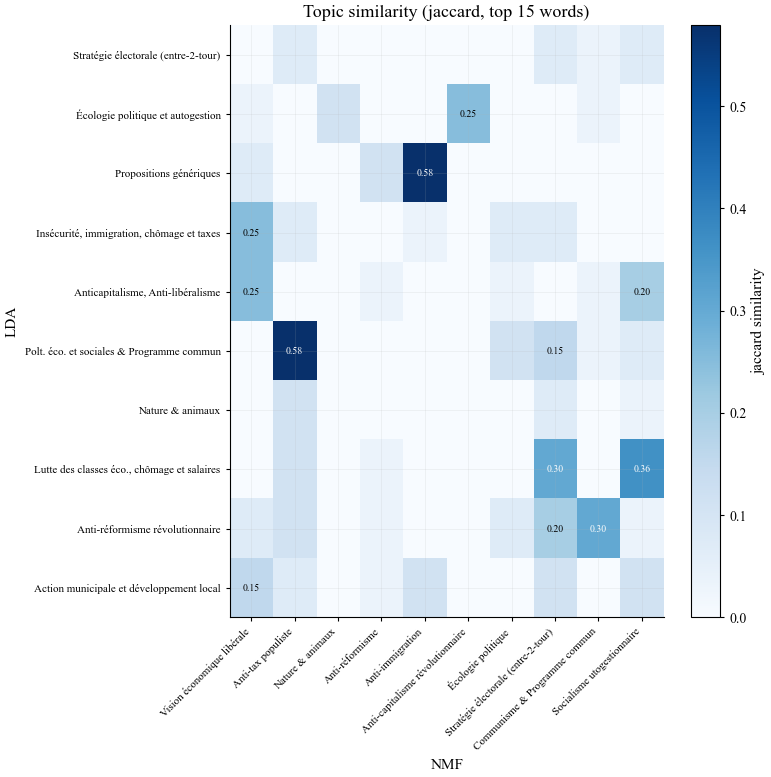

In [44]:
plot_topic_alignment_matrix(lda.get_top_words(15), nmf.get_top_words(15),
                            labels_a=lda_labels, labels_b=nmf_labels)
plt.show() 

(<Figure size 800x450 with 1 Axes>,
       Vision économique libérale  Anti-tax populiste  Nature & animaux  \
 year                                                                     
 1973                    0.277485            0.037268          0.011472   
 1978                    0.242129            0.129028          0.013942   
 1981                    0.184983            0.071674          0.014033   
 1988                    0.132128            0.027740          0.018392   
 1993                    0.177032            0.011911          0.098275   
 
       Anti-réformisme  Anti-immigration  Anti-capitalisme révolutionnaire  \
 year                                                                        
 1973         0.009505          0.016139                          0.005843   
 1978         0.015885          0.030014                          0.037162   
 1981         0.020629          0.021089                          0.046817   
 1988         0.175673          0.026795       

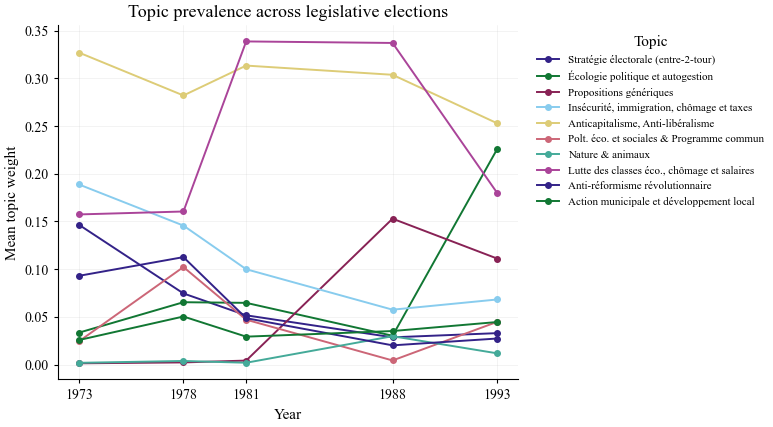

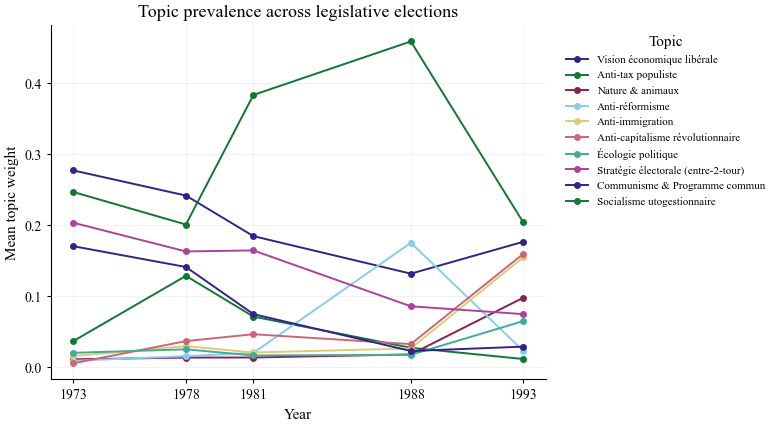

In [45]:
plot_topic_prevalence_over_time(lda.get_doc_topic_matrix(),
                                df_clean["year"], topic_labels=lda_labels)

plot_topic_prevalence_over_time(nmf.get_doc_topic_matrix(),
                                df_clean["year"], topic_labels=nmf_labels)

                                                group  rank  \
0                     Parti communiste français (PCF)     1   
1                     Parti communiste français (PCF)     2   
2                     Parti communiste français (PCF)     3   
3                               Parti socialiste (PS)     1   
4                               Parti socialiste (PS)     2   
5                               Parti socialiste (PS)     3   
6              Rassemblement pour la République (RPR)     1   
7              Rassemblement pour la République (RPR)     2   
8              Rassemblement pour la République (RPR)     3   
9            Union pour la démocratie française (UDF)     1   
10           Union pour la démocratie française (UDF)     2   
11           Union pour la démocratie française (UDF)     3   
12                                Front national (FN)     1   
13                                Front national (FN)     2   
14                                Front national (FN)  

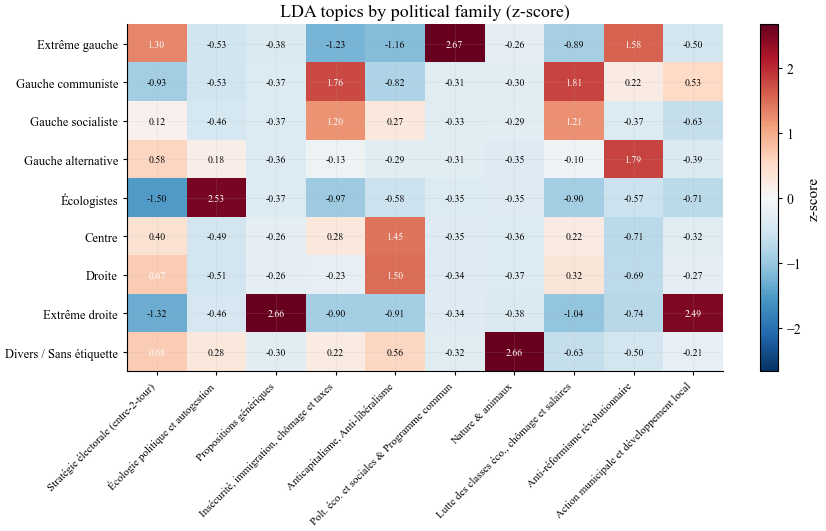

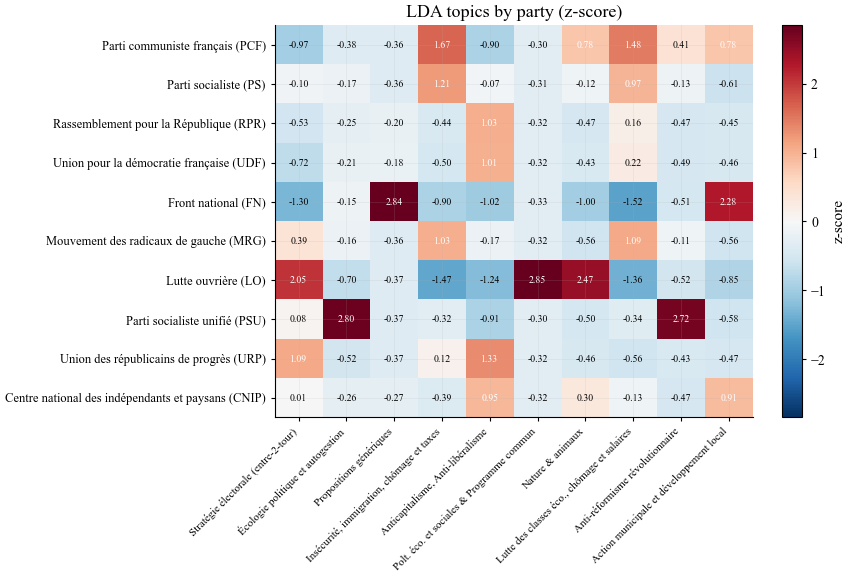

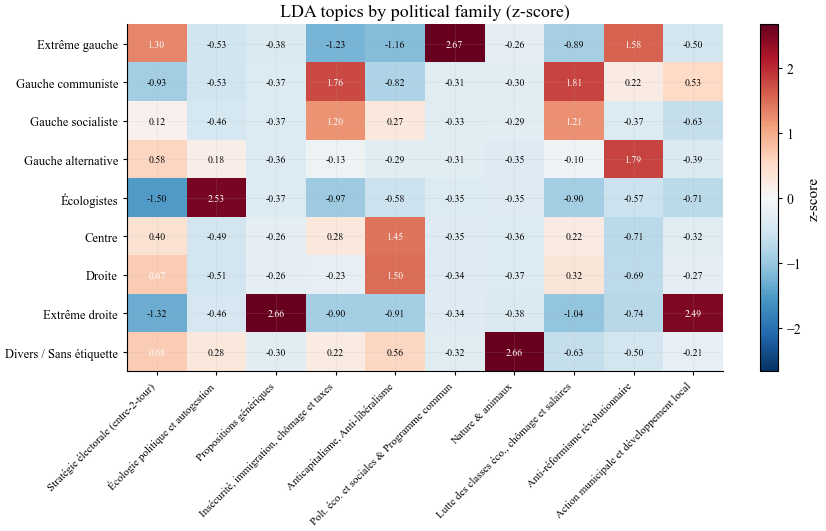

In [ ]:
# --- Topic × Party / Family analyses ---

party_dist, party_counts = topics_by_party(
    lda.get_doc_topic_matrix(), party_dummies,
    top_n_parties=10, party_counts=diagnostic["party_counts"],
    topic_labels=lda_labels,
)
plot_topic_group_heatmap(party_dist, normalize="z",
                         title="LDA topics by party (z-score)")
#print(top_topics_per_group(party_dist, top_n=3))

# Custom list of parties:
custom = ["Parti communiste français (PCF)", "Front national (FN)",
          "Lutte ouvrière (LO)"]
party_dist_custom, _ = topics_by_party(
    lda.get_doc_topic_matrix(), party_dummies, parties=custom,
    topic_labels=lda_labels,
)

# Families:
fam_dist, fam_counts = topics_by_family(
    lda.get_doc_topic_matrix(), family_dummies, topic_labels=lda_labels,
)
plot_topic_group_heatmap(fam_dist, normalize="z",
                         title="LDA topics by political family (z-score)")

## 3. State-of-the-art: BERTopic

LDA and NMF treat manifestos as bags of words and rely entirely on
co-occurrence statistics. BERTopic (Grootendorst, 2022) replaces the
bag-of-words assumption by Sentence-BERT contextual embeddings, clusters
the embedded documents with HDBSCAN, and re-extracts topic words via a
class-based TF-IDF on the resulting clusters. This is the modern endpoint
of the topic-modelling timeline reproduced in the course slides
(*"History (until BERT)"*, Churchill & Singh 2022) and it has two concrete
advantages on our corpus:

1. **Semantic understanding** — synonyms (*ouvrier* / *travailleur* /
   *salarié*) and paraphrases collapse onto the same topic without us having
   to merge them by hand.
2. **Native temporal evolution** — `topics_over_time` produces the
   year-by-year topic prevalence directly, which is the goal stated in the
   notebook title and which a Dynamic Topic Model would otherwise require
   ~1–3 hours to fit.

BERTopic operates on **raw text**, not on the lemmatised tokens used for
LDA/NMF: the embedding model handles morphology natively, and removing it
upfront would actually hurt the embeddings.

In [47]:
# Compute Sentence-BERT embeddings for the 21k manifestos.
# - On Apple Silicon (M1/M2/M3): uses MPS automatically, ~3–8 min
# - On a CPU laptop (Intel/AMD): ~15–30 min
# - On a CUDA GPU (Colab T4): ~2–4 min
# Cached to disk so kernel restarts don't redo the work.

EMBED_MODEL = "paraphrase-multilingual-MiniLM-L12-v2"  # small, fast, French-friendly
# For 1–2 points of additional topic quality at 5x slower embedding, swap to
# "paraphrase-multilingual-mpnet-base-v2"

t0 = time.time()
embeddings = compute_embeddings(
    df_clean["text"].tolist(),
    model_name = EMBED_MODEL,
    cache_path = "data/processed/bertopic_embeddings.pkl",
    batch_size = 32,
)
print(f"Embeddings: {embeddings.shape}  (elapsed: {(time.time()-t0)/60:.1f} min)")

/Users/emmaleguay/miniforge3/envs/archelec/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Batches: 100%|██████████| 656/656 [02:02<00:00,  5.36it/s]


Saved 20975 embeddings to data/processed/bertopic_embeddings.pkl
Embeddings: (20975, 384)  (elapsed: 2.3 min)


In [48]:
K_FINAL = 10

bertopic_model = BERTopicModel(
    n_topics         = K_FINAL,
    embedding_model  = EMBED_MODEL,
    min_topic_size   = 50,                   # ~0.25% of the corpus
    extra_stopwords  = list(EXTRA_STOPWORDS),
    n_gram_range     = (1, 2),               # unigrams + bigrams in topic words
    random_state     = 42,
    verbose          = True,
).fit(df_clean["text"].tolist(), embeddings=embeddings)

print(bertopic_model)
print(f"\nKept topics: {bertopic_model.n_topics}")
print(f"Outlier docs (-1): {bertopic_model.n_outliers()} "
      f"({bertopic_model.n_outliers() / len(df_clean):.1%})")

# Topic info table — useful summary
bertopic_info = bertopic_model.get_topic_info()
print(bertopic_info.head(15))
bertopic_info.to_csv("data/processed/bertopic_info.csv", index=False)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6995.72it/s]
2026-05-01 16:21:39,264 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-01 16:22:00,549 - BERTopic - Dimensionality - Completed ✓
2026-05-01 16:22:00,551 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-01 16:22:03,418 - BERTopic - Cluster - Completed ✓
2026-05-01 16:22:03,419 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-05-01 16:22:15,865 - BERTopic - Representation - Completed ✓
2026-05-01 16:22:15,879 - BERTopic - Topic reduction - Reducing number of topics
2026-05-01 16:22:15,940 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-01 16:22:29,046 - BERTopic - Representation - Completed ✓
2026-05-01 16:22:29,062 - BERTopic - Topic reduction - Reduced number of topics from 30 to 10


BERTopicModel(n_topics=9, n_outliers=1318, fitted=True)

Kept topics: 9
Outlier docs (-1): 1318 (6.3%)
   Topic  Count                             Name  \
0      0  17687                    0_de_la_et_le   
1      1   1160                   1_les_de_et_la   
2      2    199                2_les_nous_ils_qu   
3      3    185                 3_ans_de_qui_les   
4      4    139                  4_pour_de_le_et   
5      5     91                  5_les_est_la_de   
6      6     90                  6_de_nous_la_on   
7      7     54                   7_la_et_les_le   
8      8     52  8_nous_républicaine_majorité_de   

                                      Representation  \
0    [de, la, et, le, les, pour, du, en, de la, une]   
1   [les, de, et, la, pour, le, une, un, nature, du]   
2  [les, nous, ils, qu, et, qu ils, de, patrons, ...   
3  [ans, de, qui, les, le, lutte, en, pour, que, la]   
4  [pour, de, le, et, qui, la, front, les, du, du...   
5  [les, est, la, de, nous, le, travaill

In [49]:
# Top words side-by-side with LDA / NMF
print("=== BERTopic — top words per topic ===")
print(topic_words_dataframe(bertopic_model, n_words=8))

# Representative manifestos — read 2 docs per topic to validate the labels
_ = find_representative_documents(
    bertopic_model, df_clean, n_docs=2, n_chars=300,
    extra_cols=("year", "titulaire-soutien"),
)

=== BERTopic — top words per topic ===
  Topic 0 Topic 1  Topic 2 Topic 3 Topic 4       Topic 5       Topic 6  \
0      de     les      les     ans    pour           les            de   
1      la      de     nous      de      de           est          nous   
2      et      et      ils     qui      le            la            la   
3      le      la       qu     les      et            de            on   
4     les    pour       et      le     qui          nous      accepter   
5    pour      le   qu ils   lutte      la            le           une   
6      du     une       de      en   front  travailleurs  nous pouvons   
7      en      un  patrons    pour     les            on       pouvons   

        Topic 7                  Topic 8  
0            la                     nous  
1            et             républicaine  
2           les                 majorité  
3            le                       de  
4  travailleurs                 alliance  
5            de  majorité présidenti